In [1]:
import pandas as pd
import pandas as pdb



In [3]:
optimised_hydra_results = pd.read_csv("optimised_hydra_summary.csv")

In [13]:
datasets_for_optimisation = optimised_hydra_results[["dataset", "series_length"]].drop_duplicates().sort_values("series_length")["dataset"].tolist()

In [14]:
subsamples = datasets_for_optimisation[:5] + datasets_for_optimisation[5:-5:20] + datasets_for_optimisation[-5:]

In [18]:
optimised_hydra_results[optimised_hydra_results["dataset"] == "HandOutlines"]

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
112,HandOutlines,mps_hydra,42,1000,370,2709,2,16.283458,-722.567168,0.948649,0.943157,0.948123,ok,NaN
113,HandOutlines,cpu_optimised_hydra,42,1000,370,2709,2,15.895860,203.603968,0.948649,0.943157,0.948123,ok,NaN


In [19]:
max_series_length = 2700 * 2
min_series_length =

5400

In [20]:
optimised_hydra_results[optimised_hydra_results["dataset"] == "SmoothSubspace"]

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg
208,SmoothSubspace,mps_hydra,42,150,150,15,3,0.049608,11.517952,0.96,0.959997,0.959997,ok,NaN
209,SmoothSubspace,cpu_optimised_hydra,42,150,150,15,3,0.029043,0.000000,0.96,0.959997,0.959997,ok,NaN


In [15]:
subsamples

['SmoothSubspace',
 'MelbournePedestrian',
 'ItalyPowerDemand',
 'Chinatown',
 'Crop',
 'SyntheticControl',
 'SwedishLeaf',
 'InsectWingbeatSound',
 'FaceFour',
 'AllGestureWiimoteY',
 'UWaveGestureLibraryAll',
 'PigCVP',
 'PigArtPressure',
 'PigAirwayPressure',
 'HandOutlines',
 'Rock']

In [21]:
optimal_seq_len = pd.read_csv("optimal_sequence_length.csv")

In [24]:
optimal_seq_len.head()

,dataset,model,seed,n_train,n_test,series_length,n_classes,total_time,peak_memory_mb,accuracy,f1_macro,f1_weighted,status,error_msg,sequence_length
0,SmoothSubspace,mps_hydra,42,150,150,15,3,0.108357,81.772544,0.960000,0.959997,0.959997,ok,NaN,1600
1,MelbournePedestrian,mps_hydra,42,1138,2319,24,10,0.311521,192.610304,0.937904,0.935075,0.937820,ok,NaN,1600
2,ItalyPowerDemand,mps_hydra,42,67,1029,24,2,0.074807,28.573696,0.967930,0.967930,0.967930,ok,NaN,1600
3,Chinatown,mps_hydra,42,20,343,24,2,0.047477,23.085056,0.982507,0.978439,0.982671,ok,NaN,1600
4,Crop,mps_hydra,42,7200,16800,46,24,5.338155,2194.800640,0.735893,0.728760,0.728760,ok,NaN,1600


In [28]:
optimal_seq_len.groupby(["model", "sequence_length"]).agg(
    mean_latency = ("total_time", "median"),
)

mean_latency
model               sequence_length              
cpu_optimised_hydra 1600                 1.542541
                    1800                 1.502128
                    2000                 1.680212
                    2200                 1.760207
                    2400                 1.776843
                    2600                 1.884689
                    2800                 2.091143
                    3000                 1.745597
                    3200                 1.610636
                    3400                 1.635038
                    3600                 1.798569
                    3800                 1.549468
                    4000                 1.563043
                    4200                 1.689124
                    4400                 1.456839
                    4600                 1.396635
                    4800                 1.393469
                    5000                 1.362522
                    5200                 1.662745
                    5400                 1.624005
                    5600                 1.591025
                    5800                 1.556536
                    6000                 1.519654
                    6200                 1.503563
                    6400                 1.499413
mps_hydra           1600                 1.171228
                    1800                 1.152163
                    2000                 1.124557
                    2200                 1.174582
                    2400                 1.125890
                    2600                 1.144361
                    2800                 1.145375
                    3000                 1.106629
                    3200                 1.148902
                    3400                 1.134234
                    3600                 1.148628
                    3800                 1.065224
                    4000                 1.090153
                    4200                 1.105070
                    4400                 1.127955
                    4600                 1.469369
                    4800                 1.492237
                    5000                 1.484399
                    5200                 1.488238
                    5400                 1.474579
                    5600                 1.465538
                    5800                 1.784414
                    6000                 1.742465
                    6200                 1.742852
                    6400                 1.739708

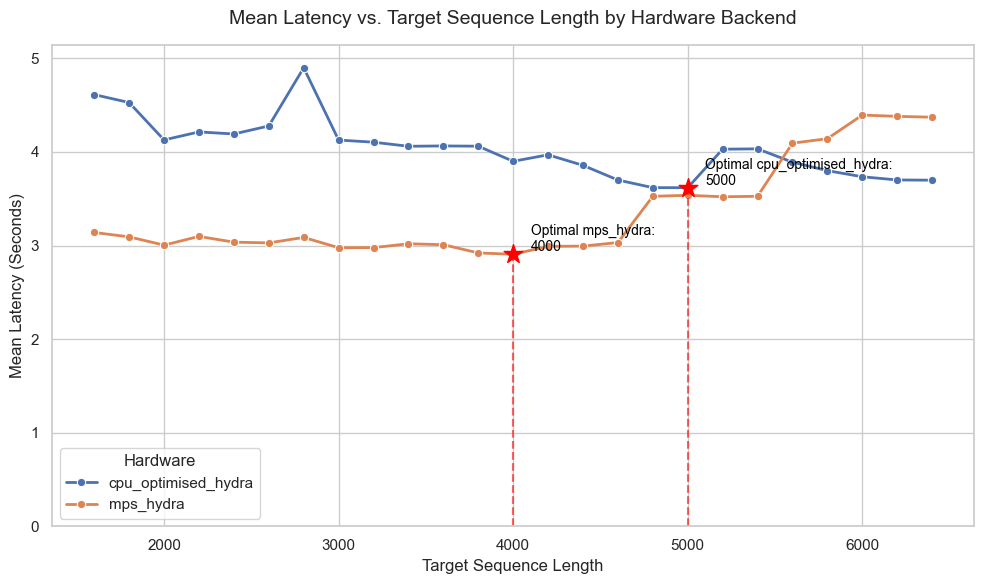

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reset the index of your grouped data so we can plot it easily
plot_df = optimal_seq_len.groupby(["model", "sequence_length"]).agg(
    mean_latency=("total_time", "mean")
).reset_index()

# 2. Set up the figure style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the main line plot
ax = sns.lineplot(
    data=plot_df,
    x="sequence_length",
    y="mean_latency",
    hue="model",
    marker="o",
    linewidth=2
)

# 4. Highlight the optimal (minimum) points for each model
for model_name in plot_df['model'].unique():
    # Filter for the specific model
    model_data = plot_df[plot_df['model'] == model_name]

    # Find the row with the lowest latency
    optimal_row = model_data.loc[model_data['mean_latency'].idxmin()]
    opt_seq_len = optimal_row['sequence_length']
    opt_latency = optimal_row['mean_latency']

    # Plot a star at the optimal point
    plt.scatter(opt_seq_len, opt_latency, color='red', s=200, marker='*', zorder=5)

    # Draw a vertical dashed line down to the x-axis
    plt.vlines(x=opt_seq_len, ymin=0, ymax=opt_latency, colors='red', linestyles='dashed', alpha=0.6)

    # Add a text annotation next to the star
    plt.text(opt_seq_len + 100, opt_latency, f'Optimal {model_name}:\n{opt_seq_len}',
             fontsize=10, color='black', verticalalignment='bottom')

# 5. Tidy up the labels and legend
plt.title("Mean Latency vs. Target Sequence Length by Hardware Backend", fontsize=14, pad=15)
plt.xlabel("Target Sequence Length", fontsize=12)
plt.ylabel("Mean Latency (Seconds)", fontsize=12)
plt.ylim(bottom=0) # Ensure y-axis starts at 0 for fair visual comparison
plt.legend(title="Hardware")
plt.tight_layout()

# plt.savefig("optimal_sequence_length.png", dpi=300)
plt.show()